In [43]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import urllib.request
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter

In [44]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt", filename="../dataset/sentiment_analysis_KOR/ratings_train.txt")
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt", filename="../dataset/sentiment_analysis_KOR/ratings_test.txt")

('../dataset/sentiment_analysis_KOR/ratings_test.txt',
 <http.client.HTTPMessage at 0x180fca0dde0>)

In [45]:
train_data = pd.read_table('../dataset/sentiment_analysis_KOR/ratings_train.txt')
test_data = pd.read_table('../dataset/sentiment_analysis_KOR/ratings_test.txt')

In [46]:
print(len(train_data))
train_data[:5] #긍정(1), 부정(0)

150000


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [47]:
train_data['document'].nunique(), train_data['label'].nunique()

(146182, 2)

In [48]:
train_data.drop_duplicates(subset=['document'],inplace=True)

In [49]:
print(len(train_data))

146183


<Axes: xlabel='label'>

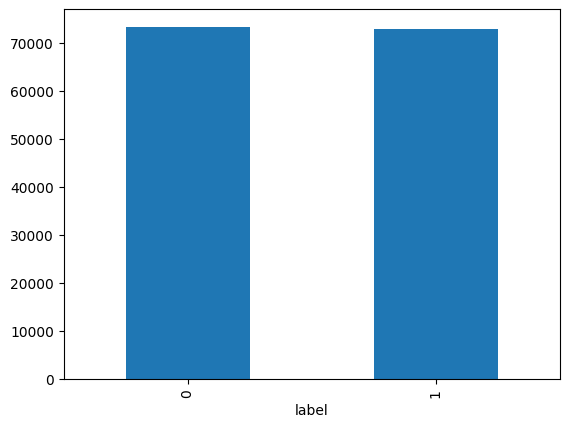

In [50]:
train_data['label'].value_counts().plot(kind = 'bar')

In [51]:
train_data.isnull().sum()

id          0
document    1
label       0
dtype: int64

In [52]:
train_data.dropna(how='any',inplace=True)
train_data.isnull().sum()

id          0
document    0
label       0
dtype: int64

In [53]:
# 전처리: 한글과 공백을 제외하고 모두 제거
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True)
train_data[:5]

,id,document,label
0,9976970,아 더빙 진짜 짜증나네요 목소리,0
1,3819312,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 솔직히 재미는 없다평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,1


In [54]:
train_data['document'] = train_data['document'].str.replace('^ +', "", regex=True) # white space 데이터를 empty value로 변경
train_data['document'].replace('', np.nan, inplace=True)
print(train_data.isnull().sum())

id            0
document    789
label         0
dtype: int64


C:\Users\jaese\AppData\Local\Temp\ipykernel_15612\3966077745.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['document'].replace('', np.nan, inplace=True)


In [55]:
train_data = train_data.dropna(how = 'any')

In [56]:
test_data.drop_duplicates(subset = ['document'], inplace=True) # document 열에서 중복인 내용이 있다면 중복 제거
test_data['document'] = test_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True) # 정규 표현식 수행
test_data['document'] = test_data['document'].str.replace('^ +', "", regex=True) # 공백은 empty 값으로 변경
test_data['document'].replace('', np.nan, inplace=True) # 공백은 Null 값으로 변경
test_data = test_data.dropna(how='any') # Null 값 제거
print('전처리 후 테스트용 샘플의 개수 :',len(test_data))

전처리 후 테스트용 샘플의 개수 : 48852


C:\Users\jaese\AppData\Local\Temp\ipykernel_15612\2256962620.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['document'].replace('', np.nan, inplace=True) # 공백은 Null 값으로 변경


In [57]:
stopwords = ['도', '는', '다', '의', '가', '이', '은', '한', '에', '하', '고', '을', '를', '인', '듯', '과', '와', '네', '들', '듯', '지', '임', '게']

In [58]:
#공백기준 토큰화

X_train = []
for sentence in tqdm(train_data['document']):
    tokens = sentence.split()
    stopwords_removed_tokens = [word for word in tokens if not word in stopwords] 
    X_train.append(stopwords_removed_tokens)

100%|██████████| 145393/145393 [00:00<00:00, 225067.84it/s]


In [59]:
print(X_train[:3])

[['아', '더빙', '진짜', '짜증나네요', '목소리'], ['흠포스터보고', '초딩영화줄오버연기조차', '가볍지', '않구나'], ['너무재밓었다그래서보는것을추천한다']]


In [60]:
X_test = []
for sentence in tqdm(test_data['document']):
    tokens = sentence.split()
    stopwords_removed_tokens = [word for word in tokens if not word in stopwords] 
    X_test.append(stopwords_removed_tokens)

  0%|          | 0/48852 [00:00<?, ?it/s]

100%|██████████| 48852/48852 [00:00<00:00, 317218.23it/s]


In [61]:
y_train = np.array(train_data['label'])
y_test = np.array(test_data['label'])

X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=1, stratify=y_train)

In [62]:
word_list = []
for sent in X_train:
    for word in sent:
      word_list.append(word)

word_counts = Counter(word_list)
print('총 단어수 :', len(word_counts))

총 단어수 : 251849


In [63]:
vocab = sorted(word_counts, key=word_counts.get, reverse=True)
threshold = 3
total_cnt = len(word_counts) # 단어의 수
rare_cnt = 0 # 등장 빈도수가 threshold보다 작은 단어의 개수
total_freq = 0 # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0 # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :',total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)


단어 집합(vocabulary)의 크기 : 251849
등장 빈도가 2번 이하인 희귀 단어의 수: 218349
단어 집합에서 희귀 단어의 비율: 86.69837879046571
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 27.283977735406413


In [64]:
# 전체 단어 개수 중 빈도수 2이하인 단어는 제거.
vocab_size = total_cnt - rare_cnt #나중에 pad와 unk를 포함하여 +2 해야됨
vocab = vocab[:vocab_size]
print('단어 집합의 크기 :', len(vocab))
print(vocab[:5])

단어 집합의 크기 : 33500
['영화', '너무', '정말', '진짜', '왜']


In [65]:
word_to_index = {}
word_to_index['<PAD>'] = 0
word_to_index['<UNK>'] = 1

In [66]:
for index, word in enumerate(vocab) :
  word_to_index[word] = index + 2


In [67]:
def texts_to_sequences(tokenized_X_data, word_to_index):
  encoded_X_data = []
  for sent in tokenized_X_data:
    index_sequences = []
    for word in sent:
      try:
          index_sequences.append(word_to_index[word])
      except KeyError:
          index_sequences.append(word_to_index['<UNK>'])
    encoded_X_data.append(index_sequences)
  return encoded_X_data

In [68]:
encoded_X_train = texts_to_sequences(X_train, word_to_index)
encoded_X_valid = texts_to_sequences(X_valid, word_to_index)
encoded_X_test = texts_to_sequences(X_test, word_to_index)

In [69]:
for sent in encoded_X_train[:2]:
  print(sent)

[24379, 1, 10498, 1, 13545, 8648]
[6008, 196]


In [70]:
index_to_word = {}
for key, value in word_to_index.items():
    index_to_word[value] = key

In [71]:
decoded_sample = [index_to_word[index] for index in encoded_X_train[0]]
print('기존의 첫번째 샘플 :', X_train[0])
print('복원된 첫번째 샘플 :', decoded_sample)

기존의 첫번째 샘플 : ['스토리보다는', '캐스팅실패네요', '김정훈', '박건형', '연기정말', '못하네요']
복원된 첫번째 샘플 : ['스토리보다는', '<UNK>', '김정훈', '<UNK>', '연기정말', '못하네요']


리뷰의 최대 길이 : 40
리뷰의 평균 길이 : 7.593204601337758


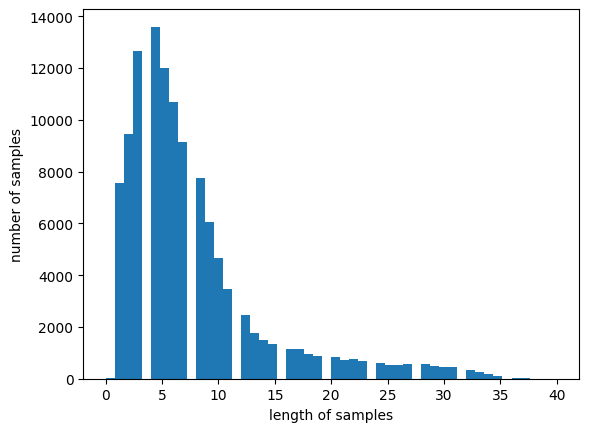

In [72]:
print('리뷰의 최대 길이 :',max(len(review) for review in encoded_X_train))
print('리뷰의 평균 길이 :',sum(map(len, encoded_X_train))/len(encoded_X_train))
plt.hist([len(review) for review in encoded_X_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [73]:
max_len = 35
def pad_sequences(sentences, max_len):
  features = np.zeros((len(sentences), max_len), dtype=int)
  for index, sentence in enumerate(sentences):
    if len(sentence) != 0:
      features[index, :len(sentence)] = np.array(sentence)[:max_len]
  return features

padded_X_train = pad_sequences(encoded_X_train, max_len=max_len)
padded_X_valid = pad_sequences(encoded_X_valid, max_len=max_len)
padded_X_test = pad_sequences(encoded_X_test, max_len=max_len)

print('훈련 데이터의 크기 :', padded_X_train.shape)
print('검증 데이터의 크기 :', padded_X_valid.shape)
print('테스트 데이터의 크기 :', padded_X_test.shape)

훈련 데이터의 크기 : (116314, 35)
검증 데이터의 크기 : (29079, 35)
테스트 데이터의 크기 : (48852, 35)


In [74]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [75]:
USE_CUDA = torch.cuda.is_available()
device = torch.device("cuda" if USE_CUDA else "cpu")
print("cpu와 cuda 중 다음 기기로 학습함:", device)

cpu와 cuda 중 다음 기기로 학습함: cuda


In [76]:
train_label_tensor = torch.tensor(np.array(y_train))
valid_label_tensor = torch.tensor(np.array(y_valid))
test_label_tensor = torch.tensor(np.array(y_test))
print(train_label_tensor[:5])

tensor([0, 1, 1, 0, 0])


In [77]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(TextClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch_size, seq_length)
        embedded = self.embedding(x)  # (batch_size, seq_length, embedding_dim)

        # LSTM은 (hidden state, cell state)의 튜플을 반환합니다
        lstm_out, (hidden, cell) = self.lstm(embedded)  # lstm_out: (batch_size, seq_length, hidden_dim), hidden: (1, batch_size, hidden_dim)

        last_hidden = hidden.squeeze(0)  # (batch_size, hidden_dim)
        logits = self.fc(last_hidden)  # (batch_size, output_dim)
        return logits


In [78]:
encoded_train = torch.tensor(padded_X_train).to(torch.int64)
train_dataset = torch.utils.data.TensorDataset(encoded_train, train_label_tensor)
train_dataloader = torch.utils.data.DataLoader(train_dataset, shuffle=True, batch_size=32)

encoded_test = torch.tensor(padded_X_test).to(torch.int64)
test_dataset = torch.utils.data.TensorDataset(encoded_test, test_label_tensor)
test_dataloader = torch.utils.data.DataLoader(test_dataset, shuffle=True, batch_size=1)

encoded_valid = torch.tensor(padded_X_valid).to(torch.int64)
valid_dataset = torch.utils.data.TensorDataset(encoded_valid, valid_label_tensor)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, shuffle=True, batch_size=1)


In [79]:
total_batch = len(train_dataloader)
print('총 배치의 수 : {}'.format(total_batch))


총 배치의 수 : 3635


In [80]:
embedding_dim = 128  #단어 임베딩 차원
hidden_dim = 128     #은닉층 크기
output_dim = 2   #분류하고자 하는 카테고리수
learning_rate = 0.01

model = TextClassifier(vocab_size + 2, embedding_dim, hidden_dim, output_dim)   #unk와 pad포함해서 vocab size+2
model.to(device)

TextClassifier(
  (embedding): Embedding(33502, 128)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [81]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [82]:
def calculate_accuracy(logits, labels):
    # _, predicted = torch.max(logits, 1)
    predicted = torch.argmax(logits, dim=1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    accuracy = correct / total
    return accuracy


In [83]:
def evaluate(model, valid_dataloader, criterion, device):
    val_loss = 0
    val_correct = 0
    val_total = 0

    model.eval()
    with torch.no_grad():
        # 데이터로더로부터 배치 크기만큼의 데이터를 연속으로 로드
        for batch_X, batch_y in valid_dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # 모델의 예측값
            logits = model(batch_X)

            # 손실을 계산
            loss = criterion(logits, batch_y)

            # 정확도와 손실을 계산함
            val_loss += loss.item()
            val_correct += calculate_accuracy(logits, batch_y) * batch_y.size(0)
            val_total += batch_y.size(0)

    val_accuracy = val_correct / val_total
    val_loss /= len(valid_dataloader)

    return val_loss, val_accuracy


In [ ]:
num_epochs = 5

# Training loop
best_val_loss = float('inf')

# Training loop
for epoch in range(num_epochs):
    # Training
    train_loss = 0
    train_correct = 0
    train_total = 0
    model.train()
    for batch_X, batch_y in train_dataloader:
        # Forward pass
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        # batch_X.shape == (batch_size, max_len)
        logits = model(batch_X)
        
        # Compute loss
        loss = criterion(logits, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        
        # 그래디언트 클리핑 추가 (gradient vanishing/exploding 방지)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        # Calculate training accuracy and loss
        train_loss += loss.item()
        train_correct += calculate_accuracy(logits, batch_y) * batch_y.size(0)
        train_total += batch_y.size(0)
        

    train_accuracy = train_correct / train_total
    train_loss /= len(train_dataloader)

    # Validation
    val_loss, val_accuracy = evaluate(model, valid_dataloader, criterion, device)

    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    # 검증 손실이 최소일 때 체크포인트 저장
    if val_loss < best_val_loss:
        print(f'Val loss improved from {best_val_loss:.4f} to {val_loss:.4f}. 체크포인트를 저장.')
        best_val_loss = val_loss
        #torch.save(model.state_dict(), '../models/best_model_checkpoint.pth')
        scripted_model = torch.jit.script(model)
        scripted_model.save("../models/kor_sentiment_lstm_scripted_model.pt")


Epoch 1/5:
Train Loss: 0.6934, Train Accuracy: 0.5010
Validation Loss: 0.6931, Validation Accuracy: 0.4975
Val loss improved from inf to 0.6931. 체크포인트를 저장.
Epoch 2/5:
Train Loss: 0.5048, Train Accuracy: 0.7339
Validation Loss: 0.4410, Validation Accuracy: 0.7806
Val loss improved from 0.6931 to 0.4410. 체크포인트를 저장.
Epoch 3/5:
Train Loss: 0.3658, Train Accuracy: 0.8243
Validation Loss: 0.4259, Validation Accuracy: 0.7900
Val loss improved from 0.4410 to 0.4259. 체크포인트를 저장.
Epoch 4/5:
Train Loss: 0.2891, Train Accuracy: 0.8638
Validation Loss: 0.4486, Validation Accuracy: 0.7905
Epoch 5/5:
Train Loss: 0.2277, Train Accuracy: 0.8927
Validation Loss: 0.4979, Validation Accuracy: 0.7857


In [ ]:
model = torch.jit.load("../models/kor_sentiment_lstm_scripted_model.pt", map_location="cpu")
model.to(device)

RecursiveScriptModule(
  original_name=TextClassifier
  (embedding): RecursiveScriptModule(original_name=Embedding)
  (lstm): RecursiveScriptModule(original_name=LSTM)
  (fc): RecursiveScriptModule(original_name=Linear)
)

In [86]:
test_loss, test_accuracy = evaluate(model, test_dataloader, criterion, device)

print(f'Best model test loss: {test_loss:.4f}')
print(f'Best model test accuracy: {test_accuracy:.4f}')

c:\Users\jaese\Desktop\ml-webapp\.venv\lib\site-packages\torch\nn\modules\module.py:1747: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  return forward_call(*args, **kwargs)


Best model test loss: 0.4279
Best model test accuracy: 0.7879


In [ ]:
index_to_tag = {0 : '부정', 1 : '긍정'}

def predict(text, model, word_to_index, index_to_tag):
    # Set the model to evaluation mode
    model.eval()

    tokens = text.split()
    stopwords_removed_tokens = [word for word in tokens if not word in stopwords] 
    
    token_indices = [word_to_index.get(token, 1) for token in stopwords_removed_tokens]

    # Convert tokens to tensor
    input_tensor = torch.tensor([token_indices], dtype=torch.long).to(device)  # (1, seq_length)

    # Pass the input tensor through the model
    with torch.no_grad():
        logits = model(input_tensor)  # (1, output_dim)

    # Get the predicted class index
    predicted_index = torch.argmax(logits, dim=1)

    # Convert the predicted index to its corresponding tag
    predicted_tag = index_to_tag[predicted_index.item()]

    return predicted_tag


In [ ]:
import pickle

pickle.dump(word_to_index, open("../artifacts/kor_sentiment_lstm_word_to_index.pkl", "wb"))

In [88]:
test_input = "이 영화 개꿀잼 ㅋㅋㅋ"
predict(test_input, model, word_to_index, index_to_tag)

'긍정'

In [ ]:
test_input = "이딴게 영화냐 ㅉㅉ"
predict(test_input, model, word_to_index, index_to_tag)

'부정'

In [ ]:
test_input = "와 개쩐다 정말 세계관 최강자들의 영화다"
predict(test_input, model, word_to_index, index_to_tag)

'긍정'